### Data Cleaning and EDA

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("premiums.xlsx", sheet_name="Sheet1")

In [3]:
df.shape

(50000, 13)

In [4]:
df.sample(3)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
43208,58,Female,Northwest,Unmarried,1,Obesity,Occasional,Salaried,> 40L,42,Diabetes,Gold,31017
41102,44,Female,Southeast,Married,4,Obesity,No Smoking,Salaried,10L - 25L,13,High blood pressure,Gold,26144
7749,35,Female,Southwest,Married,2,Underweight,No Smoking,Freelancer,10L - 25L,23,High blood pressure,Silver,16220


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    50000 non-null  int64 
 1   Gender                 50000 non-null  object
 2   Region                 50000 non-null  object
 3   Marital_status         50000 non-null  object
 4   Number Of Dependants   50000 non-null  int64 
 5   BMI_Category           50000 non-null  object
 6   Smoking_Status         49989 non-null  object
 7   Employment_Status      49998 non-null  object
 8   Income_Level           49987 non-null  object
 9   Income_Lakhs           50000 non-null  int64 
 10  Medical History        50000 non-null  object
 11  Insurance_Plan         50000 non-null  object
 12  Annual_Premium_Amount  50000 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 5.0+ MB


In [6]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [7]:
df.isna().sum()

Age                       0
Gender                    0
Region                    0
Marital_status            0
Number Of Dependants      0
BMI_Category              0
Smoking_Status           11
Employment_Status         2
Income_Level             13
Income_Lakhs              0
Medical History           0
Insurance_Plan            0
Annual_Premium_Amount     0
dtype: int64

In [8]:
cat = list(df.select_dtypes(include=["object"]).columns)
print(cat)

['Gender', 'Region', 'Marital_status', 'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level', 'Medical History', 'Insurance_Plan']


In [9]:
# have a look at categories
for i in cat:
    counts = df[i].value_counts()
    pct = round((counts/counts.sum())*100, 3)

    temp_df = pd.DataFrame(columns = ["count", "pct"])
    temp_df["count"] = counts
    temp_df["pct"] = pct
    display(temp_df)
    print("\n")

,count,pct
Gender,,
Male,27480,54.96
Female,22520,45.04


,count,pct
Region,,
Southeast,17520,35.040
Southwest,15152,30.304
Northwest,10044,20.088
Northeast,7284,14.568


,count,pct
Marital_status,,
Unmarried,25681,51.362
Married,24319,48.638


,count,pct
BMI_Category,,
Normal,23511,47.022
Overweight,11556,23.112
Underweight,7768,15.536
Obesity,7165,14.330


,count,pct
Smoking_Status,,
No Smoking,27366,54.744
Regular,15686,31.379
Occasional,6915,13.833
Smoking=0,8,0.016
Not Smoking,8,0.016
Does Not Smoke,6,0.012


,count,pct
Employment_Status,,
Salaried,20968,41.938
Freelancer,15428,30.857
Self-Employed,13602,27.205


,count,pct
Income_Level,,
<10L,18667,37.344
10L - 25L,14391,28.789
25L - 40L,10288,20.581
> 40L,6641,13.285


,count,pct
Medical History,,
No Disease,21177,42.354
Diabetes,9549,19.098
High blood pressure,7223,14.446
Thyroid,4928,9.856
Heart disease,2345,4.690
Diabetes & High blood pressure,1641,3.282
High blood pressure & Heart disease,1279,2.558
Diabetes & Thyroid,1119,2.238
Diabetes & Heart disease,739,1.478


,count,pct
Insurance_Plan,,
Bronze,21573,43.146
Silver,17098,34.196
Gold,11329,22.658


verdict : 

- standardize smoking categories

- use multiple hot coding for medical history

- handle nans

- age, NOD, income seems to have outliers

In [10]:
df['Smoking_Status'].unique()

array(['No Smoking', 'Regular', 'Occasional', nan, 'Smoking=0',
       'Does Not Smoke', 'Not Smoking'], dtype=object)

In [11]:
no_smoke = list(df['Smoking_Status'].unique()[4:])
no_smoke

['Smoking=0', 'Does Not Smoke', 'Not Smoking']

In [12]:
df_2 = df.copy()
df_2['Smoking_Status'] = df_2['Smoking_Status'].replace(no_smoke, 'No Smoking')

In [13]:
df_2['Smoking_Status'].unique()

array(['No Smoking', 'Regular', 'Occasional', nan], dtype=object)

In [14]:
df_3 = df_2
df_3 = pd.concat([df_3, df_3['Medical History'].str.get_dummies(" & ")], axis = 1)
df_3.sample(3)

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
40322,42,Male,Southwest,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,22,No Disease,Silver,18516,0,0,0,1,0
42796,25,Male,Southwest,Unmarried,1,Normal,No Smoking,Freelancer,10L - 25L,11,No Disease,Bronze,3932,0,0,0,1,0
17741,22,Female,Southeast,Unmarried,0,Underweight,Regular,Freelancer,10L - 25L,14,No Disease,Gold,11559,0,0,0,1,0


#### let's handle nan

In [15]:
df_3[df_3['Smoking_Status'].isna()]

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
177,26,Female,Southwest,Married,3,Underweight,NaN,Salaried,> 40L,69,Diabetes,Gold,22605,1,0,0,0,0
15648,47,Male,Southwest,Married,4,Normal,NaN,Freelancer,25L - 40L,32,Diabetes,Gold,26100,1,0,0,0,0
16324,45,Male,Northwest,Married,4,Overweight,NaN,Salaried,10L - 25L,16,High blood pressure & Heart disease,Silver,21881,0,1,1,0,0
16941,34,Male,Southwest,Married,5,Normal,NaN,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Gold,25865,0,1,1,0,0
16975,23,Male,Southwest,Unmarried,0,Normal,NaN,Freelancer,<10L,3,No Disease,Bronze,6001,0,0,0,1,0
18005,61,Female,Southwest,Married,2,Normal,NaN,Self-Employed,25L - 40L,27,Thyroid,Gold,32501,0,0,0,0,1
19218,19,Female,Northeast,Unmarried,0,Normal,NaN,Salaried,10L - 25L,23,No Disease,Bronze,9010,0,0,0,1,0
20335,50,Female,Northeast,Married,3,Underweight,NaN,Salaried,25L - 40L,25,High blood pressure,Gold,27317,0,0,1,0,0
22833,69,Male,Southeast,Married,2,Normal,NaN,Freelancer,<10L,9,Diabetes,Silver,23118,1,0,0,0,0
25519,54,Male,Southwest,Married,3,Overweight,NaN,Salaried,> 40L,54,High blood pressure & Heart disease,Silver,24907,0,1,1,0,0


In [16]:
df_3['Smoking_Status'].value_counts()

Smoking_Status
No Smoking    27388
Regular       15686
Occasional     6915
Name: count, dtype: int64

In [17]:
df_3.groupby(['Smoking_Status', 'No Disease']).size().unstack()

No Disease,0,1
Smoking_Status,,
No Smoking,13814,13574
Occasional,4688,2227
Regular,10312,5374


In [18]:
df_3.loc[df_3["Smoking_Status"].isna() & (df_3["No Disease"] == 1), "Smoking_Status"] = "No Smoking"
df_3.loc[df_3["Smoking_Status"].isna() & (df_3["No Disease"] == 0), "Smoking_Status"] = "Regular"


In [19]:
df_3[df_3['Smoking_Status'].isna()]

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid


In [20]:
df_3['Smoking_Status'].value_counts()

Smoking_Status
No Smoking    27390
Regular       15695
Occasional     6915
Name: count, dtype: int64

In [21]:
df_3[df_3['Employment_Status'].isna()]

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
18943,23,Female,Southwest,Unmarried,1,Underweight,No Smoking,NaN,NaN,8,No Disease,Bronze,5873,0,0,0,1,0
30421,39,Female,Southeast,Unmarried,2,Obesity,No Smoking,NaN,NaN,8,High blood pressure,Silver,20114,0,0,1,0,0


In [22]:
grp = df_3.groupby("Employment_Status")
print(grp.get_group("Salaried")['Age'].median())
print(grp.get_group("Freelancer")['Age'].median())
print(grp.get_group("Self-Employed")['Age'].median())

33.0
24.0
42.0


In [23]:
# around age 33 -> salaried, 24-> freelancer, 42 -> self employed

In [24]:
df_3.loc[df_3["Employment_Status"].isna() & (df_3["Age"] == 23), "Employment_Status"] = "Freelancer"
df_3.loc[df_3["Employment_Status"].isna() & (df_3["Age"] == 39), "Employment_Status"] = "Self-Employed"

In [25]:
df_3[df_3['Employment_Status'].isna()]

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid


In [26]:
df_3[df_3['Income_Level'].isna()]

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
997,20,Female,Southeast,Unmarried,0,Normal,No Smoking,Self-Employed,NaN,5,No Disease,Bronze,7191,0,0,0,1,0
7094,33,Male,Southeast,Married,2,Normal,Regular,Self-Employed,NaN,7,High blood pressure,Silver,18335,0,0,1,0,0
15395,27,Female,Northeast,Unmarried,2,Underweight,No Smoking,Freelancer,NaN,5,No Disease,Silver,14469,0,0,0,1,0
15452,52,Male,Northeast,Married,3,Underweight,No Smoking,Freelancer,NaN,8,Thyroid,Silver,19535,0,0,0,0,1
17438,40,Female,Northeast,Married,4,Obesity,Regular,Self-Employed,NaN,8,High blood pressure,Silver,22392,0,0,1,0,0
18943,23,Female,Southwest,Unmarried,1,Underweight,No Smoking,Freelancer,NaN,8,No Disease,Bronze,5873,0,0,0,1,0
22553,37,Female,Southeast,Unmarried,0,Underweight,Regular,Salaried,NaN,7,High blood pressure,Silver,18631,0,0,1,0,0
24317,18,Male,Southwest,Married,3,Normal,Occasional,Freelancer,NaN,6,No Disease,Silver,8484,0,0,0,1,0
30421,39,Female,Southeast,Unmarried,2,Obesity,No Smoking,Self-Employed,NaN,8,High blood pressure,Silver,20114,0,0,1,0,0
37325,19,Male,Southeast,Unmarried,0,Overweight,Occasional,Salaried,NaN,3,No Disease,Silver,9174,0,0,0,1,0


In [27]:
df_3['Income_Level'].value_counts()

Income_Level
<10L         18667
10L - 25L    14391
25L - 40L    10288
> 40L         6641
Name: count, dtype: int64

In [28]:
# bronze -> <10L, silver -> <10L
def func(x):
    if x < 10:
        return "<10L"
    if x < 25:
        return "10L - 25L"
    if x < 40:
        return "25L - 40L"
    
    return "> 40L"
    
df_3["Income_Level"] = df_3["Income_Lakhs"].map(func)
df_3[df_3['Income_Level'].isna()]

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid


In [29]:
df_3.isna().sum()

Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           0
Employment_Status        0
Income_Level             0
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
Diabetes                 0
Heart disease            0
High blood pressure      0
No Disease               0
Thyroid                  0
dtype: int64

#### handle outliers

<Axes: ylabel='Age'>

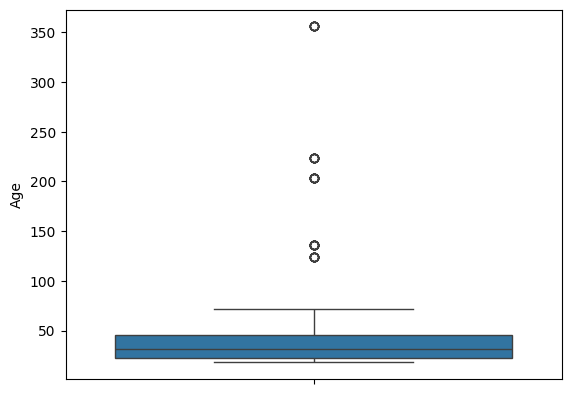

In [32]:
sns.boxplot(df['Age'])

In [33]:
q1 = np.quantile(df['Age'], 0.25)
q3 = np.quantile(df['Age'], 0.75)
iqr = q3 - q1
iqr

23.0

In [34]:
upper = q3 + 1.5*iqr
lower = q3 - 1.5*iqr
lower, upper

(10.5, 79.5)

In [35]:
# above 100 can be considered outlier

In [36]:
df.loc[df['Age'] > 100, 'Age'].min()

124

In [37]:
df.loc[df['Age'] > 100].shape

(58, 13)

In [38]:
# around median age 33 -> salaried, 24-> freelancer, 42 -> self employed
# (we will do employment group median filling of age)

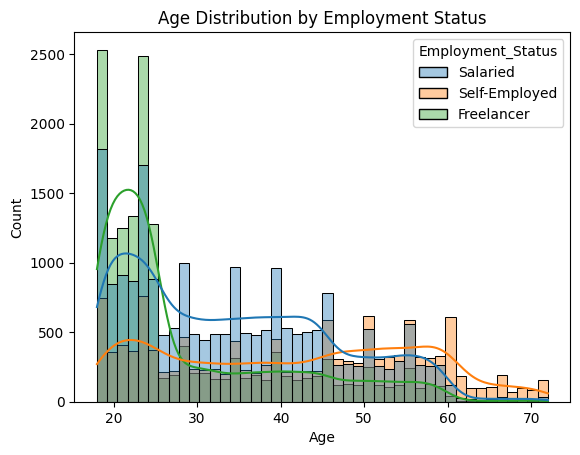

In [39]:
sns.histplot(
    data=df_3.loc[df_3["Age"] <= 100],
    x="Age",
    hue="Employment_Status",
    kde=True,
    alpha=0.4
)

plt.title("Age Distribution by Employment Status")
plt.show()

In [40]:
df_3.loc[df_3['Age']>100, 'Age'] = np.nan

In [41]:
grp = df_3.groupby("Employment_Status")
def age_fill(x):
    x['Age'] = x['Age'].fillna(x['Age'].median())

    return x

In [42]:
df_4 = grp.apply(age_fill)
df_4 = df_4.reset_index(drop=True)
df_4.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17276\1113836073.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_4 = grp.apply(age_fill)


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
0,59.0,Female,Southeast,Unmarried,0,Overweight,No Smoking,Freelancer,10L - 25L,21,No Disease,Gold,26101,0,0,0,1,0
1,22.0,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,0,0,0,1,0
2,59.0,Female,Northeast,Married,2,Obesity,Occasional,Freelancer,<10L,1,Thyroid,Silver,23798,0,0,0,0,1
3,25.0,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,0,0,0,1,0
4,29.0,Male,Northwest,Married,2,Obesity,Regular,Freelancer,<10L,7,High blood pressure,Silver,23024,0,0,1,0,0


In [43]:
df_4.loc[df_4['Age'] > 100]

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid


In [44]:
df_4[df_4['Number Of Dependants'] < 0].head()

# can't be negative

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
122,23.0,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Freelancer,10L - 25L,18,No Disease,Silver,9309,0,0,0,1,0
666,18.0,Male,Southwest,Unmarried,-3,Overweight,No Smoking,Freelancer,25L - 40L,28,No Disease,Silver,8095,0,0,0,1,0
692,19.0,Male,Northwest,Unmarried,-3,Underweight,No Smoking,Freelancer,> 40L,40,No Disease,Bronze,4641,0,0,0,1,0
1878,20.0,Male,Northeast,Unmarried,-3,Underweight,Regular,Freelancer,10L - 25L,20,Diabetes,Silver,9640,1,0,0,0,0
1984,26.0,Male,Southeast,Married,-1,Obesity,Occasional,Freelancer,25L - 40L,27,No Disease,Silver,18269,0,0,0,1,0


In [ ]:
#take absolute values only
df_4.loc[:, "Number Of Dependants"] = np.abs(df_4['Number Of Dependants'])

In [55]:
df_4.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.401480,1.716900,23.018200,15768.116320,0.260960,0.087260,0.202860,0.423540,0.120940
std,13.676628,1.492889,24.219197,8419.839675,0.439163,0.282219,0.402133,0.494124,0.326061
min,18.000000,0.000000,1.000000,3501.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,7.000000,8608.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,2.000000,17.000000,13929.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,3.000000,31.000000,22275.250000,1.000000,0.000000,0.000000,1.000000,0.000000
max,72.000000,5.000000,930.000000,43471.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: ylabel='Income_Lakhs'>

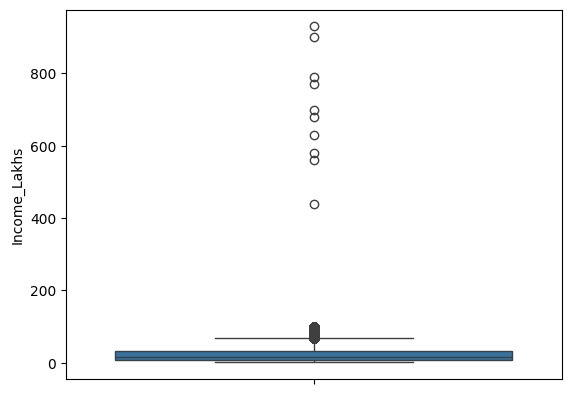

In [56]:
sns.boxplot(df_4['Income_Lakhs'])

In [57]:
df_4.loc[df_4['Income_Lakhs'] > 200, 'Income_Lakhs'] = np.nan

<Axes: xlabel='Annual_Premium_Amount', ylabel='Income_Lakhs'>

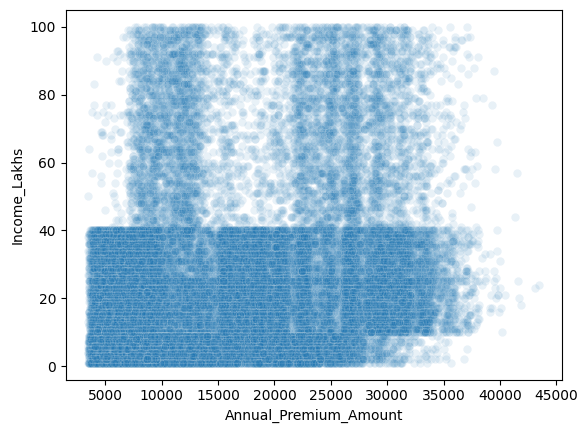

In [62]:
sns.scatterplot(x=df_4['Annual_Premium_Amount'], y=df_4['Income_Lakhs'], alpha = 0.1)

<Axes: xlabel='Insurance_Plan', ylabel='Income_Lakhs'>

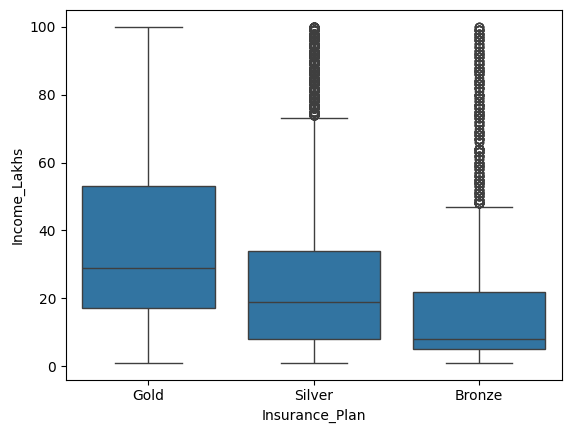

In [64]:
sns.boxplot(data = df_4, x = "Insurance_Plan", y = "Income_Lakhs")

In [ ]:
grp = df_4.groupby("Insurance_Plan")
def income_fill(x):
    x['Income_Lakhs'] = x['Income_Lakhs'].fillna(x['Income_Lakhs'].median())
    return x

In [69]:
df_5 = grp.apply(income_fill).reset_index(drop=True)
df_5.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_17276\2651737856.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_5 = grp.apply(income_fill).reset_index(drop=True)


,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
0,25.0,Male,Southeast,Unmarried,0.0,Normal,No Smoking,Freelancer,10L - 25L,15.0,No Disease,Bronze,5684,0,0,0,1,0
1,20.0,Male,Southeast,Unmarried,2.0,Overweight,No Smoking,Freelancer,10L - 25L,14.0,No Disease,Bronze,5712,0,0,0,1,0
2,19.0,Male,Southwest,Unmarried,0.0,Normal,No Smoking,Freelancer,<10L,8.0,No Disease,Bronze,4097,0,0,0,1,0
3,23.0,Female,Southeast,Unmarried,0.0,Normal,No Smoking,Freelancer,25L - 40L,29.0,No Disease,Bronze,7803,0,0,0,1,0
4,18.0,Female,Southeast,Unmarried,1.0,Normal,Occasional,Freelancer,<10L,8.0,Diabetes & High blood pressure,Bronze,8111,1,0,1,0,0


<Axes: ylabel='Income_Lakhs'>

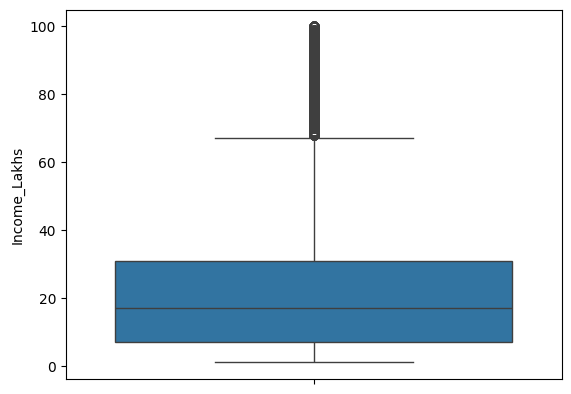

In [70]:
# now looks much better
sns.boxplot(df_5['Income_Lakhs'])

In [73]:
df_5.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.401480,1.716900,22.883180,15768.116320,0.260960,0.087260,0.202860,0.423540,0.120940
std,13.676628,1.492889,22.162659,8419.839675,0.439163,0.282219,0.402133,0.494124,0.326061
min,18.000000,0.000000,1.000000,3501.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,7.000000,8608.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,2.000000,17.000000,13929.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,3.000000,31.000000,22275.250000,1.000000,0.000000,0.000000,1.000000,0.000000
max,72.000000,5.000000,100.000000,43471.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# export the cleaned data
df_5.to_excel("proc.xlsx", index = False)